In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import tensorflow as tf
import random
import keras

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../../"))
from LSTM.preprocessing import parse_start_time, convert_to_datetime, create_sequences, prepare_sequences_from_cycles
from AST_LSTM.paper_sota.keras_model import ATSLSTM


In [3]:
SP = 50
LOOK_BACK = 30
SAMPLE_NUM = SP - LOOK_BACK
TIMESTEPS = 168 - SP

In [4]:
def set_seed(seed=42):
    """
    Set seed for reproducibility
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed()

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [5]:
discharge_dataset = pd.read_csv("../../../dataset/processed/preprocessed_discharge_data.csv")

In [6]:
discharge_data_B0006 = discharge_dataset[discharge_dataset["battery_id"] == "B0006"].copy()
discharge_data_B0018 = discharge_dataset[discharge_dataset["battery_id"] == "B0018"].copy()

## Extract features

### Take 175 timesteps in each of the cycle, and then concatenate 168 cycles, each cycle have 5 features

In [7]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../../dataset/processed/data"

X_B0006 = prepare_sequences_from_cycles(discharge_data_B0006, data_path, columns)
X_B0018 = prepare_sequences_from_cycles(discharge_data_B0018, data_path, columns)

X = np.concatenate([np.array(X_B0006), np.array(X_B0018)], axis=0)

100%|██████████| 132/132 [00:00<00:00, 280.26it/s]


In [8]:
# (cycles, each rows in a cycle, features)
X.shape

(300, 175, 5)

In [9]:
timesteps = X.shape[1]
features = X.shape[2]
latent_dim = 12

In [10]:
from keras.api.models import Model, Sequential
from keras.api.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from keras.api.utils import plot_model
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError

input_layer = Input(shape=(timesteps, features))
encoded = LSTM(64, activation='sigmoid', return_sequences=True)(input_layer)
encoded = LSTM(32, activation='sigmoid', return_sequences=False)(encoded)
encoded = Dense(latent_dim, activation='relu', name='bottleneck')(encoded)

decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(32, activation='sigmoid', return_sequences=True)(decoded)
decoded = LSTM(64, activation='sigmoid', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features, activation='linear'))(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [11]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 175, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 175, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 175, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 175, 32)        │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 175, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 175, 5)         │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,649 (240.82 KB)

 Trainable params: 61,649 (240.82 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('autoencoder/best_autoencoder.keras', save_best_only=True)
]

autoencoder.fit(X, X, epochs=30, batch_size=16, validation_split=0.2, callbacks=callbacks, verbose=1)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 277ms/step - loss: 0.1644 - root_mean_squared_error: 0.3979 - val_loss: 0.0246 - val_root_mean_squared_error: 0.1569
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - loss: 0.0480 - root_mean_squared_error: 0.2187 - val_loss: 0.0306 - val_root_mean_squared_error: 0.1750
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - loss: 0.0371 - root_mean_squared_error: 0.1926 - val_loss: 0.0177 - val_root_mean_squared_error: 0.1329
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - loss: 0.0340 - root_mean_squared_error: 0.1841 - val_loss: 0.0199 - val_root_mean_squared_error: 0.1410
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - loss: 0.0335 - root_mean_squared_error: 0.1830 - val_loss: 0.0190 - val_root_mean_squared_error: 0.1379
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - loss: 0.0333 - root_mean_squared_error: 0.1823 - val_loss: 0.0194 - val_root_mean_squared_error: 0.1391
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step

In [13]:
encoded_features = encoder.predict(X)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


In [14]:
encoded_features.shape

(300, 12)

In [15]:
capacity = pd.concat([
    discharge_data_B0006["Capacity"],
    discharge_data_B0018["Capacity"]
], axis=0).reset_index(drop=True)

In [16]:
from sklearn.preprocessing import MinMaxScaler

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

In [17]:
combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [18]:
# (Cycles, seq_len, features)
combined_features.shape

(300, 13)

In [19]:
features_b0006 = combined_features[:168]
features_b0018 = combined_features[168:]

X_b0006, y_b0006 = create_sequences(features_b0006, LOOK_BACK)
X_b0018, y_b0018 = create_sequences(features_b0018, LOOK_BACK)

X = np.concatenate([X_b0006, X_b0018], axis=0)
y = np.concatenate([y_b0006, y_b0018], axis=0)

In [20]:
X, y = create_sequences(combined_features, LOOK_BACK)

# Encoder-Decoder Model for future prediction

In [21]:
timesteps = X.shape[1]
n_features = X.shape[2]

timesteps, n_features

(30, 13)

In [22]:
from keras.api.models import Sequential
from keras.api.layers import LSTM, RepeatVector, TimeDistributed, Dense, InputLayer, Dropout

model = Sequential()

model.add(InputLayer((timesteps, n_features)))

model.add(LSTM(64, return_sequences=True, activation='tanh'))

model.add(LSTM(32, return_sequences=True, activation='tanh'))

model.add(LSTM(16, return_sequences=False, activation='tanh'))

model.add(Dense(16, activation='relu'))

model.add(Dense(n_features, activation='linear'))

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │           221 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,013 (140.68 KB)

 Trainable params: 36,013 (140.68 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
import tensorflow as tf
from keras.api import backend as K

def monotonic_mse_loss(alpha=0.001):
    def loss_fn(y_true, y_pred):
        y_true_cap = y_true[:, -1]
        y_pred_cap = y_pred[:, -1]

        mse = tf.reduce_mean(tf.square(y_true - y_pred))

        diffs = y_pred_cap[1:] - y_pred_cap[:-1]
        penalty = tf.reduce_mean(tf.square(tf.maximum(diffs, 0.0)))
        total_loss = mse + alpha * penalty

        return total_loss
    return loss_fn

In [25]:
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError
from keras.api.regularizers import L2

# Callback to stop training when validation loss stops improving
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

cp = ModelCheckpoint('models/model.keras', save_best_only=True, monitor='val_loss')
model.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [26]:
model.fit(X, y, epochs=100, batch_size=32, callbacks=[es, cp])

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0224 - root_mean_squared_error: 0.1497
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0162 - root_mean_squared_error: 0.1273


c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,root_mean_squared_error
  current = self.get_monitor_value(logs)
c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0120 - root_mean_squared_error: 0.1096
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0088 - root_mean_squared_error: 0.0940
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0063 - root_mean_squared_error: 0.0791
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0043 - root_mean_squared_error: 0.0655
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0031 - root_mean_squared_error: 0.0554
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0024 - root_mean_squared_error: 0.0489
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - root_mean_squared_error: 0.0445
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0017 - root_mean_squared_error: 0.0410
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0015 - root_mean_squared_error: 0.0382
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0013 - root_mean_squared_error: 0.0361
Epoch 1

In [27]:
initial_input = X[SAMPLE_NUM-1:SAMPLE_NUM]
X_input = initial_input.reshape(1, LOOK_BACK, latent_dim + 1)

initial_capacity = X_input[0, 0, -1]
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = 1.4

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold voltage: {threshold} Ah")

Initial capacity: 1.979626548250818 Ah
Threshold voltage: 1.4 Ah


In [28]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + SP + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + SP + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

predicted_rul = i

Predicted capacity for cycle 51: 1.7163974470075787
Predicted capacity for cycle 52: 1.7181856307536472
Predicted capacity for cycle 53: 1.716522393411015
Predicted capacity for cycle 54: 1.712147220127691
Predicted capacity for cycle 55: 1.7059356814952913
Predicted capacity for cycle 56: 1.698614547342383
Predicted capacity for cycle 57: 1.6907288950403911
Predicted capacity for cycle 58: 1.6826073262743837
Predicted capacity for cycle 59: 1.6744409386344774
Predicted capacity for cycle 60: 1.6663287224588026
Predicted capacity for cycle 61: 1.658311661008369
Predicted capacity for cycle 62: 1.6503941678651315
Predicted capacity for cycle 63: 1.6425626870273713
Predicted capacity for cycle 64: 1.6348267812559907
Predicted capacity for cycle 65: 1.6271638572147924
Predicted capacity for cycle 66: 1.6195579944831533
Predicted capacity for cycle 67: 1.6119996303001711
Predicted capacity for cycle 68: 1.6044799375019365
Predicted capacity for cycle 69: 1.596996604212187
Predicted capacit

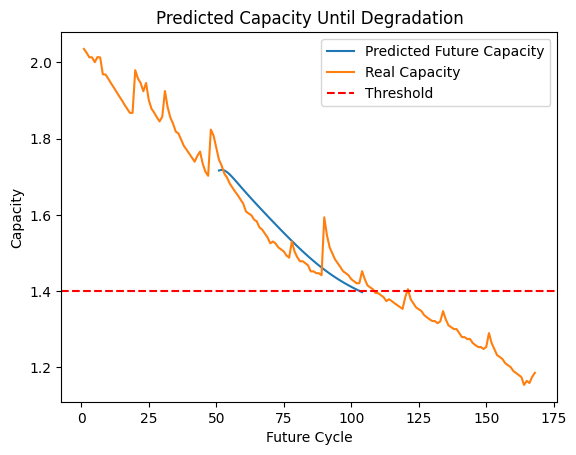

In [29]:
import matplotlib.pyplot as plt

cycles = list(range(SP + 1, SP + len(predicted_capacities) + 1))

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_B0006["cycle_number"], discharge_data_B0006["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()

In [30]:
COMPARE_TIMESTEPS = min(TIMESTEPS, predicted_rul)

true_capacities = discharge_data_B0006["Capacity"].values[SP:SP + COMPARE_TIMESTEPS]

predicted_capacities = predicted_capacities[:COMPARE_TIMESTEPS]

len(true_capacities), len(predicted_capacities)

(53, 53)

In [31]:
# Compute RMSE
rmse = np.sqrt(mean_squared_error(true_capacities, predicted_capacities))
# Compute AE
true_rul = 108 - SP
ae = abs(predicted_rul - true_rul)

print(f"rmse: {rmse:.4f}")
print(f"ae: {ae}")
print(f"predicted_rul: {predicted_rul}")

rmse: 0.0442
ae: 5
predicted_rul: 53


## Test on other batteries

In [32]:
discharge_data_b0005 = discharge_dataset[discharge_dataset["battery_id"] == "B0005"].copy()

In [33]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data_b0005, data_path, columns)

100%|██████████| 168/168 [00:00<00:00, 184.80it/s]


In [34]:
encoded_features = encoder.predict(X)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [35]:
capacity = discharge_data_b0005["Capacity"]

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [36]:
X, y = create_sequences(combined_features, LOOK_BACK)

initial_input = X[SAMPLE_NUM-1:SAMPLE_NUM]
X_input = initial_input.reshape(1, LOOK_BACK, latent_dim + 1)

initial_capacity = X_input[0, 0, -1]
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = 1.4

print(f"Initial capacity: {initial_capacity_real} Ah")

Initial capacity: 1.8470259949329195 Ah


In [37]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + SP + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + SP + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

predicted_rul = i

Predicted capacity for cycle 51: 1.7282104874311464
Predicted capacity for cycle 52: 1.726962710393076
Predicted capacity for cycle 53: 1.7238793047410883
Predicted capacity for cycle 54: 1.7195600947954495
Predicted capacity for cycle 55: 1.7145034926786538
Predicted capacity for cycle 56: 1.7090772617553973
Predicted capacity for cycle 57: 1.7035237737866424
Predicted capacity for cycle 58: 1.6979882279759548
Predicted capacity for cycle 59: 1.6925379498124908
Predicted capacity for cycle 60: 1.68719915723233
Predicted capacity for cycle 61: 1.6819747331909272
Predicted capacity for cycle 62: 1.6768479904637663
Predicted capacity for cycle 63: 1.6717892854853447
Predicted capacity for cycle 64: 1.6668022473878232
Predicted capacity for cycle 65: 1.6618650674611128
Predicted capacity for cycle 66: 1.6569634665964301
Predicted capacity for cycle 67: 1.6520844206185428
Predicted capacity for cycle 68: 1.6472197894179308
Predicted capacity for cycle 69: 1.642364790680251
Predicted capaci

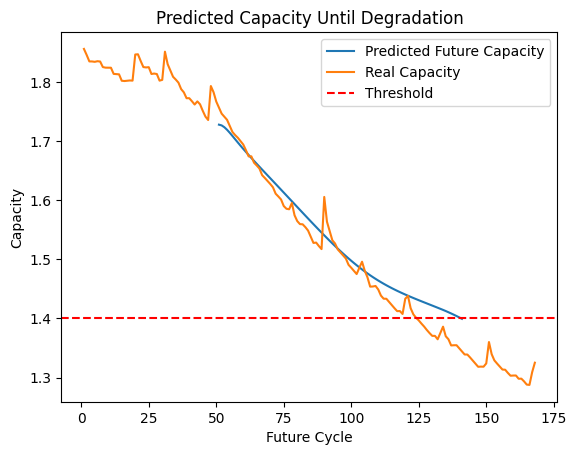

In [38]:
import matplotlib.pyplot as plt

cycles = list(range(SP + 1, SP + len(predicted_capacities) + 1))

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_b0005["cycle_number"], discharge_data_b0005["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()

In [39]:
COMPARE_TIMESTEPS = min(TIMESTEPS, predicted_rul)

true_capacities = discharge_data_b0005["Capacity"].values[SP:SP + COMPARE_TIMESTEPS]

predicted_capacities = predicted_capacities[:COMPARE_TIMESTEPS]

len(true_capacities), len(predicted_capacities)

(90, 90)

In [40]:
rmse = np.sqrt(mean_squared_error(true_capacities, predicted_capacities))
true_rul = 124 - SP
ae = abs(predicted_rul - true_rul)

print(f"rmse: {rmse:.4f}")
print(f"ae: {ae}")
print(f"predicted_rul: {predicted_rul}")

rmse: 0.0263
ae: 16
predicted_rul: 90


Test on other batteries (B0007)

In [41]:
discharge_data_b0007 = discharge_dataset[discharge_dataset["battery_id"] == "B0007"].copy()

In [42]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data_b0007, data_path, columns)

100%|██████████| 168/168 [00:00<00:00, 244.04it/s]


In [43]:
encoded_features = encoder.predict(X)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [44]:
capacity = discharge_data_b0007["Capacity"]

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [45]:
X, y = create_sequences(combined_features, LOOK_BACK)

initial_input = X[SAMPLE_NUM-1:SAMPLE_NUM]
X_input = initial_input.reshape(1, LOOK_BACK, latent_dim + 1)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = 1.4

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold capacity: {threshold} Ah")

Initial capacity: 1.8807805437609768 Ah
Threshold capacity: 1.4 Ah


In [46]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)  # shape: (1, 1, 33)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + SP + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + SP + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

predicted_rul = i

Predicted capacity for cycle 51: 1.774332316399282
Predicted capacity for cycle 52: 1.772563446851242
Predicted capacity for cycle 53: 1.7696041410515162
Predicted capacity for cycle 54: 1.765820360918303
Predicted capacity for cycle 55: 1.7615359016030374
Predicted capacity for cycle 56: 1.7569945232775208
Predicted capacity for cycle 57: 1.7523604774874602
Predicted capacity for cycle 58: 1.7477343854841954
Predicted capacity for cycle 59: 1.7431620692673921
Predicted capacity for cycle 60: 1.7386622728713745
Predicted capacity for cycle 61: 1.7342385053197287
Predicted capacity for cycle 62: 1.7298787482066715
Predicted capacity for cycle 63: 1.7255630000977604
Predicted capacity for cycle 64: 1.7212960566585636
Predicted capacity for cycle 65: 1.7170620395573524
Predicted capacity for cycle 66: 1.7128493105325653
Predicted capacity for cycle 67: 1.7086520504534215
Predicted capacity for cycle 68: 1.7044611358585966
Predicted capacity for cycle 69: 1.7002744613339384
Predicted capac

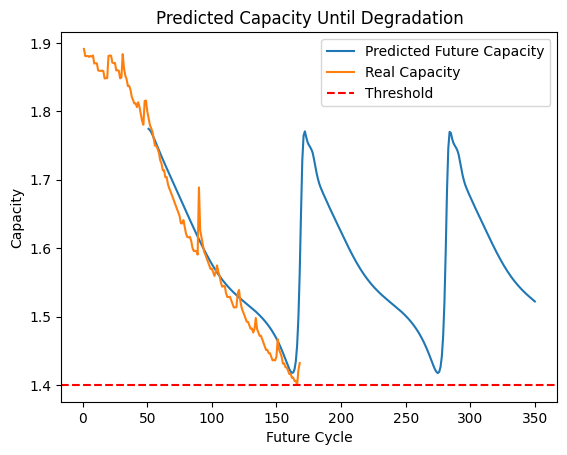

In [47]:
import matplotlib.pyplot as plt

cycles = list(range(SP + 1, SP + len(predicted_capacities) + 1))

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_b0007["cycle_number"], discharge_data_b0007["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()

In [48]:
COMPARE_TIMESTEPS = min(TIMESTEPS, predicted_rul)

true_capacities = discharge_data_b0007["Capacity"].values[SP:SP + COMPARE_TIMESTEPS]

predicted_capacities = predicted_capacities[:COMPARE_TIMESTEPS]

len(true_capacities), len(predicted_capacities)

(118, 118)

In [49]:
# Compute RMSE
rmse = np.sqrt(mean_squared_error(true_capacities, predicted_capacities))
# Compute AE
true_rul = 167 - SP
ae = abs(predicted_rul - true_rul)

print(f"rmse: {rmse:.4f}")
print(f"ae: {ae}")

rmse: 0.0267
ae: 183
